In [41]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Charger les données
ratings = pd.read_csv('ratings.csv')
movies = pd.read_csv('movies.csv')

# On relie les 2 fichiers via la colonne commune "movieId"
df = ratings.merge(movies, on='movieId')

df.head()



,userId,movieId,rating,timestamp,title,genres
0,1,16,4.0,1217897793,Casino (1995),Crime|Drama
1,1,24,1.5,1217895807,Powder (1995),Drama|Sci-Fi
2,1,32,4.0,1217896246,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Mystery|Sci-Fi|Thriller
3,1,47,4.0,1217896556,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,4.0,1217896523,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [42]:
df.isnull().sum()


userId       0
movieId      0
rating       0
timestamp    0
title        0
genres       0
dtype: int64

In [43]:
df.describe()

,userId,movieId,rating,timestamp
count,105339.000000,105339.000000,105339.000000,1.053390e+05
mean,364.924539,13381.312477,3.516850,1.130424e+09
std,197.486905,26170.456869,1.044872,1.802660e+08
min,1.000000,1.000000,0.500000,8.285650e+08
25%,192.000000,1073.000000,3.000000,9.711008e+08
50%,383.000000,2497.000000,3.500000,1.115154e+09
75%,557.000000,5991.000000,4.000000,1.275496e+09
max,668.000000,149532.000000,5.000000,1.452405e+09


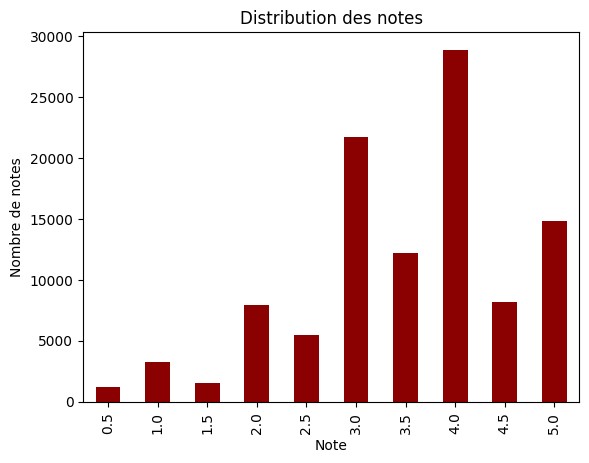

In [44]:
# 4. Distribution des notes (graphique)
df['rating'].value_counts().sort_index().plot(kind='bar', color='darkred')
plt.title('Distribution des notes')
plt.xlabel('Note')
plt.ylabel('Nombre de notes')
plt.show()

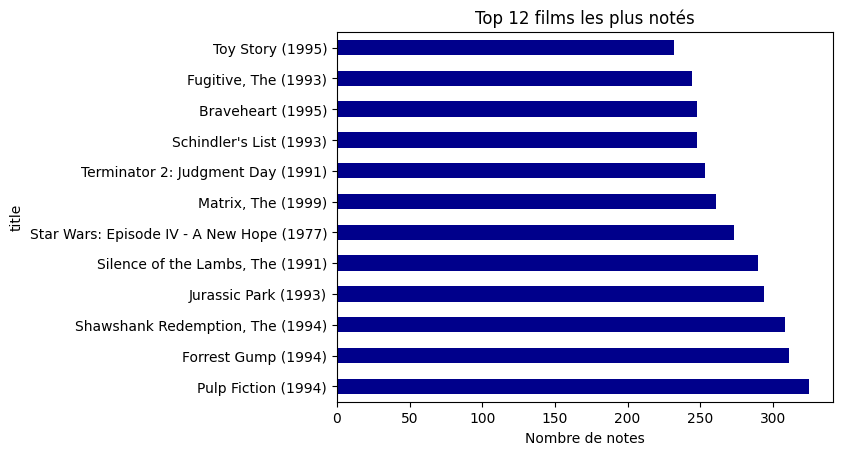

In [45]:
# 5. Top 12 films les plus notés
top_films = df.groupby('title')['rating'].count().sort_values(ascending=False).head(12)
top_films.plot(kind='barh', color='darkblue')
plt.title('Top 12 films les plus notés')
plt.xlabel('Nombre de notes')
plt.show()

In [46]:
import numpy as np
import pickle

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

In [47]:
#values pour garder les valeurs numériques sans les titres de films
X = df[['userId', 'movieId']].values
y = df['rating'].values

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"Train : {X_train.shape} | Test : {X_test.shape}")

Train : (84271, 2) | Test : (21068, 2)


In [49]:
knn = KNeighborsRegressor(n_neighbors=20)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

RMSE : 0.9652


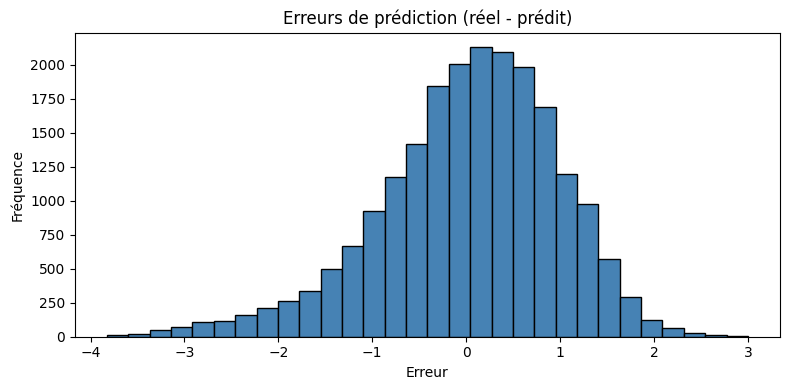

In [50]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE : {rmse:.4f}") # Différence entre les valeurs réelles et prédites en moyenne. + faible est mieux, puisque l'erreur est moins haute.

# Visualiser les prédictions vs réelles
plt.figure(figsize=(8, 4))
plt.hist(y_test - y_pred, bins=30, color='steelblue', edgecolor='black')
plt.title("Erreurs de prédiction (réel - prédit)")
plt.xlabel("Erreur")
plt.ylabel("Fréquence")
plt.tight_layout()
plt.show()

In [51]:
#Pour tester différents k
resultats = []

for k in [5, 10, 20, 30, 50]:
    knn_test = KNeighborsRegressor(n_neighbors=k)
    knn_test.fit(X_train, y_train)
    y_pred_test = knn_test.predict(X_test)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    resultats.append((k, rmse_test))
    print(f"k={k} | RMSE : {rmse_test:.4f}")

k=5 | RMSE : 1.0052
k=10 | RMSE : 0.9731
k=20 | RMSE : 0.9652
k=30 | RMSE : 0.9686
k=50 | RMSE : 0.9745


In [52]:
with open('model.pkl', 'wb') as f:
    pickle.dump(knn, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✅ model.pkl et scaler.pkl sauvegardés !")

✅ model.pkl et scaler.pkl sauvegardés !


Part 2 - Amélioration avec 2e Dataset TMDB

In [53]:
tmdb = pd.read_csv('tmdb_5000_movies.csv')
tmdb.head()

df['title_clean'] = df['title'].str.replace(r'\s*\(\d{4}\)', '', regex=True).str.strip()

print("MovieLens sample:")
print(df['title_clean'].head())
print("\nTMDB sample:")
print(tmdb['title'].head())

MovieLens sample:
0                                Casino
1                                Powder
2    Twelve Monkeys (a.k.a. 12 Monkeys)
3                  Seven (a.k.a. Se7en)
4                   Usual Suspects, The
Name: title_clean, dtype: str

TMDB sample:
0                                      Avatar
1    Pirates of the Caribbean: At World's End
2                                     Spectre
3                       The Dark Knight Rises
4                                 John Carter
Name: title, dtype: str


In [54]:
tmdb.info()

<class 'pandas.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   str    
 2   homepage              1712 non-null   str    
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   str    
 5   original_language     4803 non-null   str    
 6   original_title        4803 non-null   str    
 7   overview              4800 non-null   str    
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   str    
 10  production_countries  4803 non-null   str    
 11  release_date          4802 non-null   str    
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   str    
 15  status                4803 non-n

In [55]:
# Merger via le titre nettoyé
df_ameliorer = df.merge(tmdb, left_on='title_clean', right_on='title', how='left')

# Nbre de films qui ont matché
matched = df_ameliorer['popularity'].notna().sum()
total = len(df_ameliorer)
print(f"Films matchés : {matched}/{total}")

# Remplir les valeurs manquantes avec la moyenne
df_ameliorer['popularity'] = df_ameliorer['popularity'].fillna(df_ameliorer['popularity'].mean())
df_ameliorer['vote_average'] = df_ameliorer['vote_average'].fillna(df_ameliorer['vote_average'].mean())
df_ameliorer['budget'] = df_ameliorer['budget'].fillna(0)

df_ameliorer.head()

Films matchés : 51182/105559


,userId,movieId,rating,timestamp,title_x,genres_x,title_clean,budget,genres_y,homepage,...,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title_y,vote_average,vote_count
0,1,16,4.0,1217897793,Casino (1995),Crime|Drama,Casino,52000000.0,"[{""id"": 18, ""name"": ""Drama""}, {""id"": 80, ""name...",NaN,...,"[{""iso_3166_1"": ""FR"", ""name"": ""France""}, {""iso...",1995-11-22,116112375.0,178.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,No one stays at the top forever.,Casino,7.800000,1307.0
1,1,24,1.5,1217895807,Powder (1995),Drama|Sci-Fi,Powder,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.814454,NaN
2,1,32,4.0,1217896246,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Mystery|Sci-Fi|Thriller,Twelve Monkeys (a.k.a. 12 Monkeys),0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.814454,NaN
3,1,47,4.0,1217896556,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,Seven (a.k.a. Se7en),0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.814454,NaN
4,1,50,4.0,1217896523,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,"Usual Suspects, The",0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.814454,NaN


In [56]:
# Nouvelles features avec TMDB
X_ameliorer = df_ameliorer[['userId', 'movieId', 'popularity', 'vote_average', 'budget']].values
y_ameliorer = df_ameliorer['rating'].values

X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X_ameliorer, y_ameliorer, test_size=0.2, random_state=42
)

scaler_e = StandardScaler()
X_train_e = scaler_e.fit_transform(X_train_e)
X_test_e = scaler_e.transform(X_test_e)

knn_ameliorer = KNeighborsRegressor(n_neighbors=20)
knn_ameliorer.fit(X_train_e, y_train_e)

y_pred_e = knn_ameliorer.predict(X_test_e)
rmse_ameliorer = np.sqrt(mean_squared_error(y_test_e, y_pred_e))

print(f"RMSE sans TMDB : {rmse:.4f}")
print(f"RMSE avec TMDB : {rmse_ameliorer:.4f}")

RMSE sans TMDB : 0.9652
RMSE avec TMDB : 0.9675


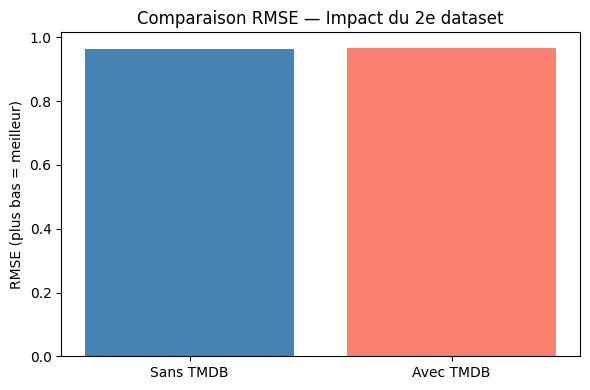

In [57]:
# Graphique comparatif
plt.figure(figsize=(6, 4))
plt.bar(['Sans TMDB', 'Avec TMDB'], 
        [rmse, rmse_ameliorer], 
        color=['steelblue', 'salmon'])
plt.title('Comparaison RMSE — Impact du 2e dataset')
plt.ylabel('RMSE (plus bas = meilleur)')
plt.tight_layout()
plt.show()

CONCLUSION : Même en tentant d'améliorer mon modèle à l'aide d'un second dataset, il n'y a aucun changement au RMSE, le niveau d'erreur est pratiquement identique.

In [58]:
# ════════════════════════════════════════════════════
# PARTIE 3 — Modèle amélioré avec genres
# ════════════════════════════════════════════════════

# 1. Extraire les genres en colonnes (One-Hot Encoding)
genres_split = df['genres'].str.get_dummies('|')
print("Genres disponibles :")
print(genres_split.columns.tolist())
print(f"\n{len(genres_split.columns)} genres au total")

Genres disponibles :
['(no genres listed)', 'Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']

20 genres au total


In [59]:
# 2. Combiner avec le dataset principal
df_genres = pd.concat([df[['userId', 'movieId', 'rating']], genres_split], axis=1)
print(df_genres.head())
print(df_genres.shape)

   userId  movieId  rating  (no genres listed)  Action  Adventure  Animation  \
0       1       16     4.0                   0       0          0          0   
1       1       24     1.5                   0       0          0          0   
2       1       32     4.0                   0       0          0          0   
3       1       47     4.0                   0       0          0          0   
4       1       50     4.0                   0       0          0          0   

   Children  Comedy  Crime  ...  Film-Noir  Horror  IMAX  Musical  Mystery  \
0         0       0      1  ...          0       0     0        0        0   
1         0       0      0  ...          0       0     0        0        0   
2         0       0      0  ...          0       0     0        0        1   
3         0       0      0  ...          0       0     0        0        1   
4         0       0      1  ...          0       0     0        0        1   

   Romance  Sci-Fi  Thriller  War  Western  
0    

In [60]:
# 3. Préparer X et y
feature_cols = ['userId', 'movieId'] + genres_split.columns.tolist()

X_genres = df_genres[feature_cols].values
y_genres = df_genres['rating'].values

X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(
    X_genres, y_genres, test_size=0.2, random_state=42
)

scaler_g = StandardScaler()
X_train_g = scaler_g.fit_transform(X_train_g)
X_test_g = scaler_g.transform(X_test_g)

print(f"Nombre de features : {len(feature_cols)}")

Nombre de features : 22


In [61]:
# 4. Entraîner le nouveau modèle
knn_genres = KNeighborsRegressor(n_neighbors=20)
knn_genres.fit(X_train_g, y_train_g)

y_pred_g = knn_genres.predict(X_test_g)
rmse_genres = np.sqrt(mean_squared_error(y_test_g, y_pred_g))

print(f"RMSE sans genres : {rmse:.4f}")
print(f"RMSE avec genres : {rmse_genres:.4f}")

RMSE sans genres : 0.9652
RMSE avec genres : 0.9896


In [62]:
# 5. Sauvegarder le nouveau modèle
import pickle

with open('model.pkl', 'wb') as f:
    pickle.dump(knn_genres, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler_g, f)

# Sauvegarder aussi la liste des genres pour l'API
genre_columns = genres_split.columns.tolist()
with open('genres.pkl', 'wb') as f:
    pickle.dump(genre_columns, f)

print("✅ model.pkl, scaler.pkl et genres.pkl sauvegardés !")
print(f"Genres sauvegardés : {genre_columns}")

✅ model.pkl, scaler.pkl et genres.pkl sauvegardés !
Genres sauvegardés : ['(no genres listed)', 'Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']
